# Greedy Knapsack Problem (Fractional)
In this lab, we explore the Fractional Knapsack Problem, a fundamental optimization problem that demonstrates the Greedy Algorithmic Paradigm.
We will implement it using greedy selection (based on value-to-weight ratio) and analyze its time and space complexity.

- Created by Dr. Ajay

# Problem Definition
Given a set of
n
n items, each with:
Value vi
Weight wi
A knapsack with maximum capacity **W**

Goal: maximize total value that can be put in the knapsack.
Constraint: You may take fractions of items.

Greedy Strategy:

*  Sort items by decreasing ratio vi/wi
*  Select items fully until knapsack is full.
*  Take fraction of the next item if capacity remains.

Maximum value in Knapsack = 240.0


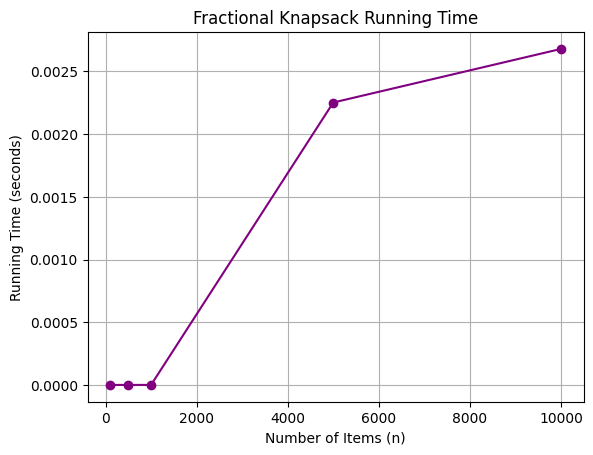

In [1]:
#write code for the above problem
import time
import random
import matplotlib.pyplot as plt

def fractional_knapsack(values, weights, capacity):
    n = len(values)
    items = [(values[i], weights[i], values[i] / weights[i]) for i in range(n)]
    items.sort(key=lambda x: x[2], reverse=True)

    total_value = 0.0
    remaining_capacity = capacity

    for v, w, ratio in items:
        if remaining_capacity >= w:
            total_value += v
            remaining_capacity -= w
        else:
            total_value += v * (remaining_capacity / w)
            break

    return total_value


# Example usage
values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50
print("Maximum value in Knapsack =", fractional_knapsack(values, weights, capacity))


# Measure running time for different input sizes
sizes = [100, 500, 1000, 5000, 10000]
times = []

for n in sizes:
    values = [random.randint(10, 1000) for _ in range(n)]
    weights = [random.randint(1, 100) for _ in range(n)]
    capacity = sum(weights) // 2

    start = time.time()
    fractional_knapsack(values, weights, capacity)
    end = time.time()
    times.append(end - start)

# Plot graph
plt.plot(sizes, times, marker='o', color='purple')
plt.xlabel("Number of Items (n)")
plt.ylabel("Running Time (seconds)")
plt.title("Fractional Knapsack Running Time")
plt.grid(True)
plt.show()


In this lab, we implement Huffman Coding, a greedy algorithm used for lossless data compression.
It assigns variable-length binary codes to input symbols based on their frequencies, ensuring that more frequent symbols receive shorter codes and less frequent symbols receive longer codes.

This algorithm constructs a binary tree (Huffman Tree) where each leaf node represents a character, and the path from the root to a leaf gives the character’s binary code.

Use:
Huffman Tree Construction using a Min-Priority Queue (Min-Heap).
Code generation for each character.
Encoding and decoding using the generated Huffman codes.
Complexity analysis and comparison with fixed-length encoding.

# Pseudocode:
1. Create a leaf node for each character and insert all nodes into a
2. min-heap by frequency.
   *  While the heap has more than one node:
   * Extract two nodes with the lowest frequencies.
   * Create a new internal node with frequency = sum of the two.
   *  Set the two extracted nodes as left and right children.
   *  Insert the new node back into the min-heap.
3. The remaining node is the root of the Huffman Tree.

4. Traverse the tree:
   * Assign 0 for left edge and 1 for right edge.
   * The resulting paths from root to leaves give Huffman codes.

Original Text: huffman coding algorithm
Huffman Codes: {'a': '000', 'h': '001', 'l': '0100', 'd': '0101', 'n': '011', 'm': '1000', 'o': '1001', 'i': '1010', 't': '10110', 'r': '10111', ' ': '1100', 'f': '1101', 'g': '1110', 'u': '11110', 'c': '11111'}
Encoded Text: 0011111011011101100000001111001111110010101101001111101100000010011101001101111010101100011000
Decoded Text: huffman coding algorithm


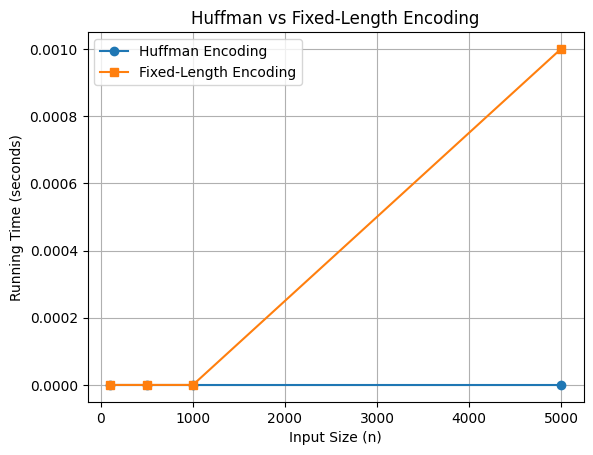

In [2]:
# write code for above
import heapq
import time
import matplotlib.pyplot as plt
from collections import defaultdict

class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    # For priority queue comparison
    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(frequencies):
    heap = [Node(char, freq) for char, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]


def generate_codes(root, current_code="", codes=None):
    if codes is None:
        codes = {}
    if root is None:
        return codes

    if root.char is not None:
        codes[root.char] = current_code
        return codes

    generate_codes(root.left, current_code + "0", codes)
    generate_codes(root.right, current_code + "1", codes)
    return codes


def encode(text, codes):
    return "".join(codes[ch] for ch in text)


def decode(encoded_text, root):
    decoded = []
    node = root
    for bit in encoded_text:
        node = node.left if bit == "0" else node.right
        if node.char is not None:
            decoded.append(node.char)
            node = root
    return "".join(decoded)


# Example usage
text = "huffman coding algorithm"
frequencies = defaultdict(int)
for ch in text:
    frequencies[ch] += 1

root = build_huffman_tree(frequencies)
codes = generate_codes(root)

encoded = encode(text, codes)
decoded = decode(encoded, root)

print("Original Text:", text)
print("Huffman Codes:", codes)
print("Encoded Text:", encoded)
print("Decoded Text:", decoded)


# Complexity experiment: compare Huffman vs fixed-length encoding
sizes = [100, 500, 1000, 5000]
huffman_times = []
fixed_times = []

for n in sizes:
    sample_text = "".join(random.choice("abcdefg") for _ in range(n))
    frequencies = defaultdict(int)
    for ch in sample_text:
        frequencies[ch] += 1

    start = time.time()
    root = build_huffman_tree(frequencies)
    codes = generate_codes(root)
    encode(sample_text, codes)
    end = time.time()
    huffman_times.append(end - start)

    start = time.time()
    fixed_encoded = "".join(format(ord(ch), '08b') for ch in sample_text)
    end = time.time()
    fixed_times.append(end - start)

plt.plot(sizes, huffman_times, marker='o', label="Huffman Encoding")
plt.plot(sizes, fixed_times, marker='s', label="Fixed-Length Encoding")
plt.xlabel("Input Size (n)")
plt.ylabel("Running Time (seconds)")
plt.title("Huffman vs Fixed-Length Encoding")
plt.legend()
plt.grid(True)
plt.show()
